In [36]:
import cv2
from sklearn.mixture import GaussianMixture
import numpy as np
from pathlib import Path
from skimage.feature import local_binary_pattern
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
from natsort import natsorted

In [37]:
def readImage(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return img

def preprocessImage(img, size=(150,150)):
    #img = cv2.GaussianBlur(img,(5,5),0)
    #img = cv2.medianBlur(img,3)
    #img = cv2.bilateralFilter(img, 5, 75, 75)

    #img = cv2.equalizeHist(img)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    img = cv2.resize(img, size)
    return img

In [38]:
def detectBackground(image, brightThresh=0.4, edgeThresh=10):
    brightPixels = image > 180
    brightRatio = np.sum(brightPixels) / brightPixels.size

    edges = cv2.Canny(image, 100, 200)
    edgeDensity = np.sum(edges[brightPixels]) / np.sum(brightPixels)

    #return brightRatio > brightThresh and edgeDensity < edgeThresh
    return edgeDensity < edgeThresh

In [39]:
def detectLowDetailRegion(image, k=3, lbp_std_thresh=0.05, radius=1, method='uniform'):
    h, w = image.shape

    # Calculate LBP
    n_points = 8 * radius
    lbp = local_binary_pattern(image, n_points, radius, method=method)

    # Flatten image for K-Means
    pixels = image.reshape((-1, 1)).astype(np.float32)

    # K-Means clustering
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    # Create segmented mask for each cluster
    labels_image = labels.reshape((h, w))

    # Analyze each segment
    for i in range(k):
        mask = (labels_image == i)
        region_lbp = lbp[mask]
        lbp_std = np.std(region_lbp)

        if lbp_std < lbp_std_thresh:
            return True  # Found a large low-texture region

    return False


In [40]:
currentPath = Path().cwd()
targetPath = currentPath.parent / 'data' / 'KGT_noDefect'
imsNoF = natsorted([str(file) for file in targetPath.iterdir() if file.is_file()])

print(imsNoF[0])
'''
namesFiltered = []
for image in imsNoF:
    if detectLowDetailRegion(preprocessImage(readImage(image))): namesFiltered.append(Path(image).name)

namesFiltered = sorted(namesFiltered)
'''
# currently not in use to save time

c:\Users\max\OneDrive\Desktop\KIT\Semester 3\Seminar_KiP\data\KGT_noDefect\N (1).png


'\nnamesFiltered = []\nfor image in imsNoF:\n    if detectLowDetailRegion(preprocessImage(readImage(image))): namesFiltered.append(Path(image).name)\n\nnamesFiltered = sorted(namesFiltered)\n'

In [41]:
def show_background_candidates_with_border_check(
    image, k=7, morph_kernel_size=5, intensity_threshold=90, min_area=500
):
    
    gray = image
    h, w = gray.shape

    pixels = gray.reshape((-1, 1)).astype(np.float32)

    gmm = GaussianMixture(n_components=k, covariance_type="tied", max_iter=100, random_state=0)
    gmm.fit(pixels)
    labels = gmm.predict(pixels)
    labels_image = labels.reshape((h, w))

    # Bright cluster selection
    cluster_means = [pixels[labels == i].mean() for i in range(k)]
    cluster_bright_pixel_counts = [(pixels[labels == i] > intensity_threshold).sum() for i in range(k)]
    cluster_sizes = [np.sum(labels == i) for i in range(k)]

    bright_clusters = []
    for i in range(k):
        if cluster_sizes[i] == 0:
            continue
        bright_ratio = cluster_bright_pixel_counts[i] / cluster_sizes[i]
        if bright_ratio > 0.05:
            bright_clusters.append(i)

    bright_mask = np.isin(labels_image, bright_clusters).astype(np.uint8) * 255

    # Clean mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
    cleaned_mask = cv2.morphologyEx(bright_mask, cv2.MORPH_OPEN, kernel)

    # Remove small areas
    num_labels, labels_cc, stats, _ = cv2.connectedComponentsWithStats(cleaned_mask)
    filtered_mask = np.zeros_like(cleaned_mask)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            filtered_mask[labels_cc == i] = 255

    # Now: treat all filtered regions as a single candidate
    final_candidate = filtered_mask.astype(bool)

    # Check how many borders it touches
    touches = 0
    if np.any(final_candidate[0, :]):
        touches += 1
    if np.any(final_candidate[-1, :]):
        touches += 1
    if np.any(final_candidate[:, 0]):
        touches += 1
    if np.any(final_candidate[:, -1]):
        touches += 1

    print(f"Unified candidate touches {touches} borders")

    # Only keep it if it touches at most 3 borders
    final_background_mask = np.zeros_like(filtered_mask)
    if touches <= 3:
        final_background_mask[final_candidate] = 255

    # Visualization
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original Grayscale")
    plt.imshow(gray, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Merged Background Candidate")
    plt.imshow(filtered_mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Final Background (Touches ≤ 3 Borders)")
    overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    overlay[final_background_mask == 255] = [0, 0, 255]  # red overlay
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Unified candidate touches 4 borders


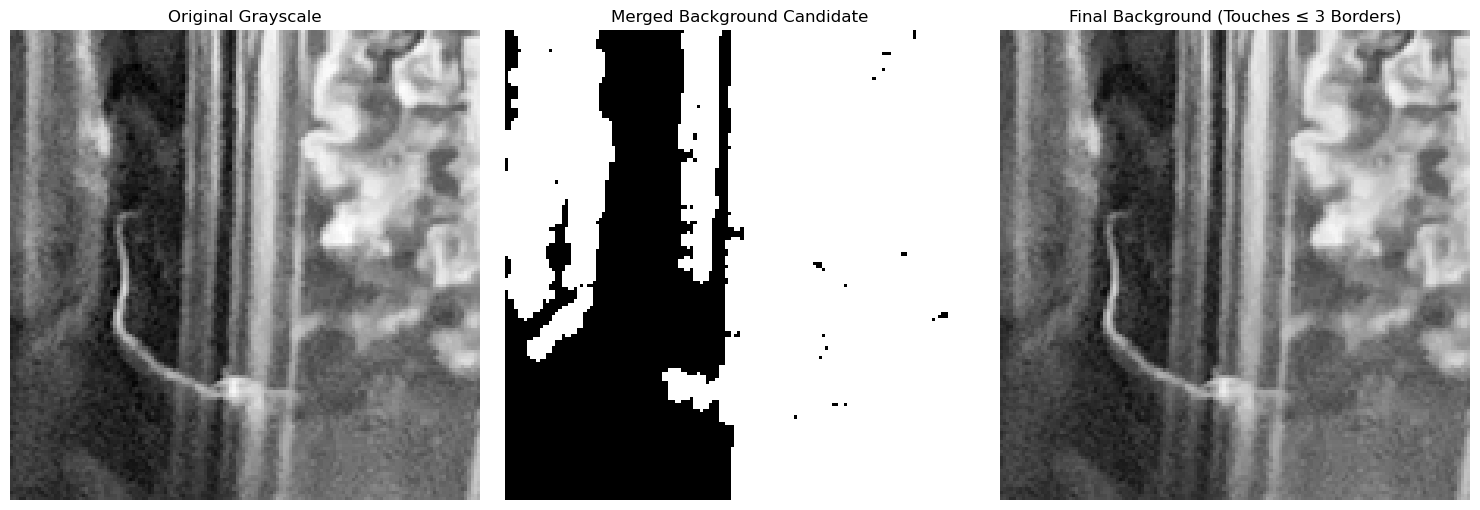

Unified candidate touches 0 borders


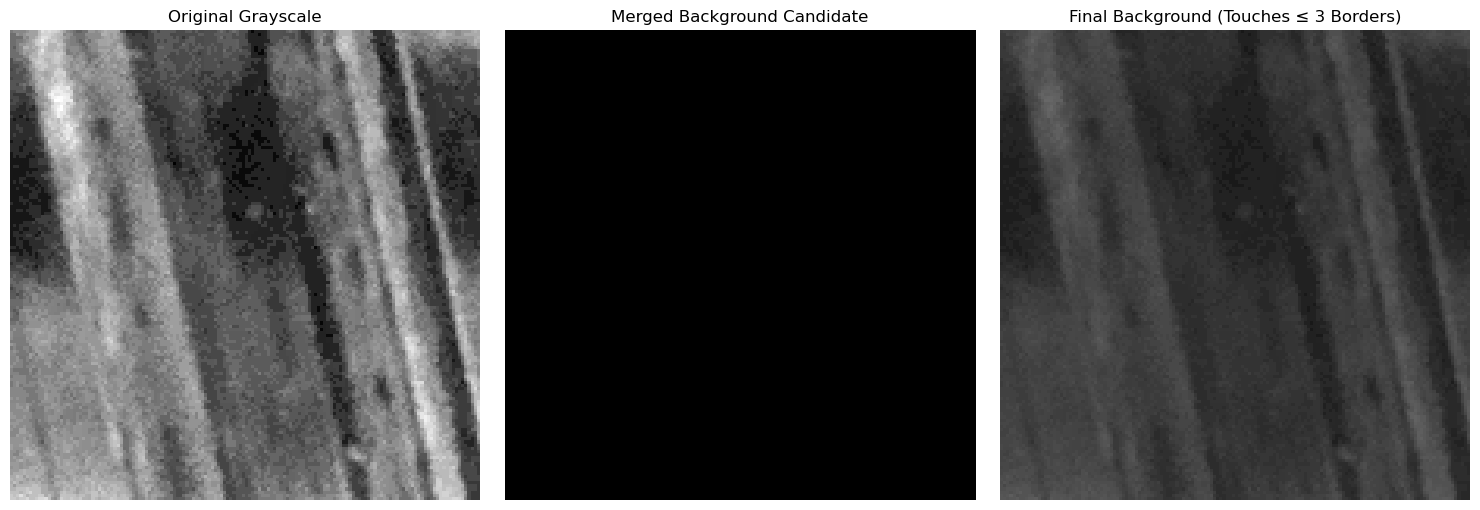

Unified candidate touches 4 borders


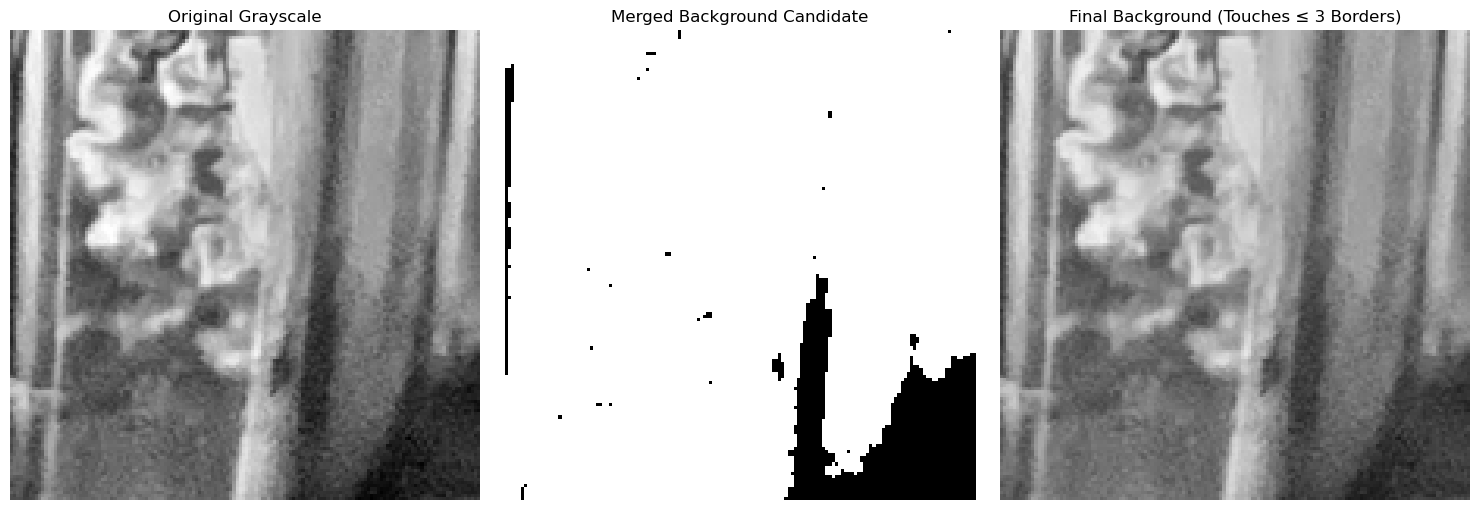

Unified candidate touches 3 borders


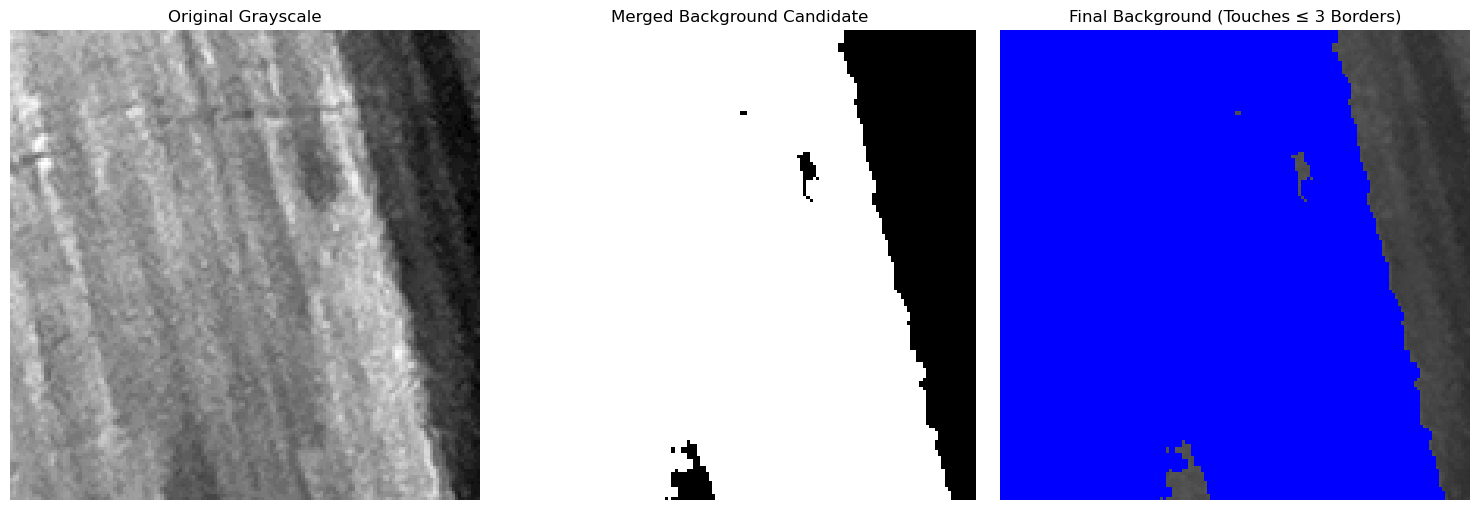

Unified candidate touches 2 borders


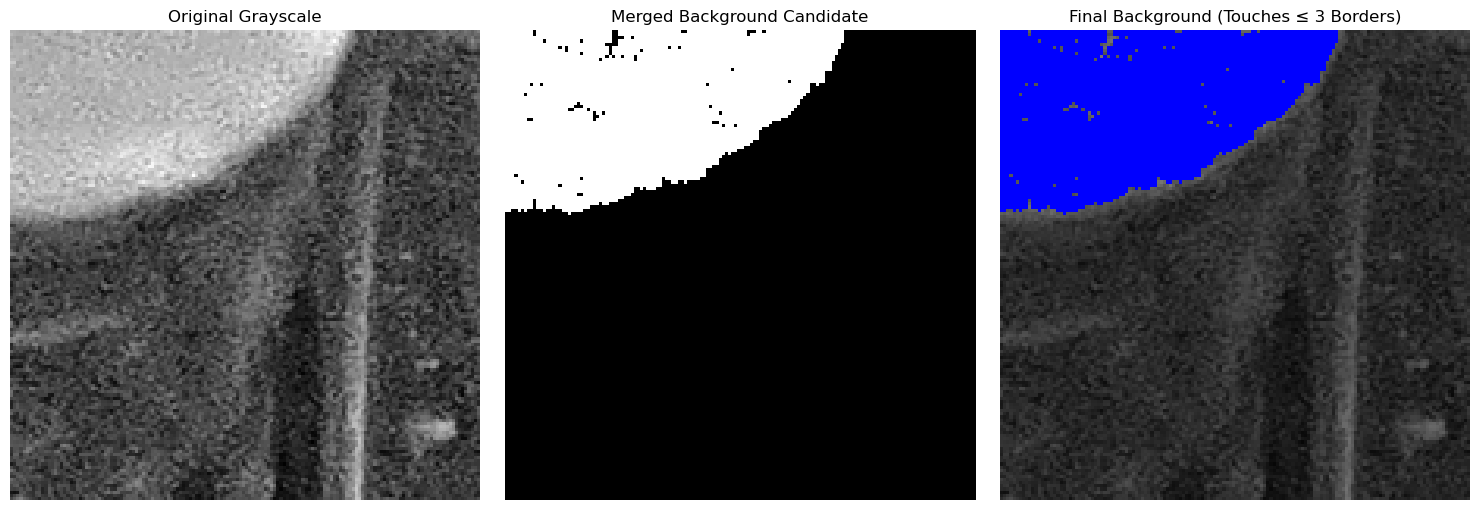

In [42]:
for i in range(1170,1175):
    show_background_candidates_with_border_check(preprocessImage(readImage(imsNoF[i])))

In [43]:
def detect_background_presence(
    gray, k=7, morph_kernel_size=5, intensity_threshold=90, min_area=500, visualize=False
):
    h, w = gray.shape
    pixels = gray.reshape((-1, 1)).astype(np.float32)

    gmm = GaussianMixture(n_components=k, covariance_type="tied", max_iter=100, random_state=0)
    labels = gmm.fit_predict(pixels).reshape(h, w)

    bright_clusters = [
        i for i in range(k)
        if np.sum(labels == i) > 0 and 
           (gray[labels == i] > intensity_threshold).mean() > 0.05
    ]

    bright_mask = np.isin(labels, bright_clusters).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
    cleaned_mask = cv2.morphologyEx(bright_mask, cv2.MORPH_OPEN, kernel)

    num_labels, labels_cc, stats, _ = cv2.connectedComponentsWithStats(cleaned_mask)
    filtered_mask = np.zeros_like(cleaned_mask)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            filtered_mask[labels_cc == i] = 255

    mask = filtered_mask.astype(bool)
    touches_top = np.any(mask[0, :])
    touches_bottom = np.any(mask[-1, :])

    # Accept only if it touches one (not both) of top or bottom
    has_valid_background = np.any(mask) and (touches_top ^ touches_bottom)

    if visualize:
        overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        if has_valid_background:
            overlay[mask] = [0, 0, 255]  # highlight in red
        plt.figure(figsize=(10, 4))
        plt.imshow(overlay)
        plt.title("Detected Background (Red)" if has_valid_background else "No Valid Background")
        plt.axis("off")
        plt.show()

    return has_valid_background

In [44]:
def process_image_safe(image_path):
    try:
        img = readImage(image_path)
        pre = preprocessImage(img)
        if detect_background_presence(pre, visualize=False):
            return Path(image_path).name
    except Exception as e:
        print(f"Error: {e}")
    return None

with ThreadPoolExecutor() as executor:
    results = list(executor.map(process_image_safe, imsNoF))

namesFilteredV2 = [r for r in results if r]

In [51]:
print(Path(imsNoF[3080]).name)

N (2577).png


In [68]:
i = 344
print(Path(imsNoF[i]).name)
cv2.calcHist(cv2.imread(imsNoF[i],cv2.IMREAD_GRAYSCALE),[0],None,[20],[0,256])

N (424).png


array([[  0.],
       [  0.],
       [ 28.],
       [100.],
       [ 13.],
       [  9.],
       [  0.],
       [  0.],
       [  0.],
       [  0.],
       [  0.],
       [  0.],
       [  0.],
       [  0.],
       [  0.],
       [  0.],
       [  0.],
       [  0.],
       [  0.],
       [  0.]], dtype=float32)